
## Data Preparation and Setup Before Modelling

In [ ]:
%pip install faiss-cpu sentence-transformers datasets rank_bm25

In [11]:
import pandas as pd
import numpy as np
import ast
import faiss
import torch
import re
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sentence_transformers import SentenceTransformer
import gc
import pickle
from datasets import Dataset as HFDataset


SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# FILE PATHS
ALIGNED_RESUME_FILE   = 'df_RecSys_resumes_cleaned.csv'
ONET_OCCUPATIONS_FILE = 'Unified_Occupation_Dataset.csv'

# EVALUATION CONSTANTS
K_MAX  = 50
K_VALS = [1, 10, 50]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Device: cuda


In [12]:
# Helper Functions
def preserve_tech_syntax(text: str) -> str:
    """Retains domain-specific tokens (C++, .NET, C#). Lowercases everything."""
    if not isinstance(text, str):
        return ""
    return ' '.join(re.sub(r'[^a-z0-9\+\#\.]', ' ', str(text).lower()).split())


def safe_parse(x):
    """Safely parse a stringified Python list into an actual list."""
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return [x]
    return []


print("Helper functions defined.")

Helper functions defined.


In [ ]:
# Load & Normalise O*NET Occupation Dataset
print("Loading O*NET Occupations...")
df_occ = pd.read_csv(ONET_OCCUPATIONS_FILE)

# Global controlled vocabulary from O*NET ontology
with open('master_vocab.pkl', 'rb') as f:
    master_vocab = pickle.load(f)
vocab_set = set(master_vocab)
print(f"Global vocabulary size: {len(master_vocab)} tokens")

# Apply preserve_tech_syntax to every feature token
df_occ['Clean_Feature'] = df_occ['Feature_Name'].apply(preserve_tech_syntax)

# Aggregate features per occupation (deduplicated)
df_occ = (
    df_occ
    .groupby(['ONET_SOC_Code', 'Title'])['Clean_Feature']
    .apply(lambda x: ' '.join(pd.unique(x)))
    .reset_index()
)

# Build occupation text representations
df_occ['Text'] = (
    df_occ['Title'] + " " + df_occ['Clean_Feature']
)

occ_texts     = df_occ['Text'].tolist()
occ_codes_map = df_occ['ONET_SOC_Code'].to_numpy()

# Fast lookup dict for occupation text retrieval
onet_dict = {
    code: f"{title} {' '.join(grp['Clean_Feature'].tolist())}"
    for (code, title), grp in df_occ.groupby(['ONET_SOC_Code', 'Title'])
}

print(f"O*NET occupations loaded: {len(df_occ)} unique occupations")

Loading O*NET Occupations...
Global vocabulary size: 366 tokens
O*NET occupations loaded: 875 unique occupations


In [5]:
# Load & Normalise Resume Dataset
print("Loading Resumes...")
df_resumes = pd.read_csv(ALIGNED_RESUME_FILE)
df_resumes['Aligned_Text'] = df_resumes['Aligned_Text'].apply(safe_parse)

print(f"Resumes loaded         : {len(df_resumes)}")
print(f"Unique occupation codes: {df_resumes['Mapped_ONET_Code'].nunique()}")
print(df_resumes[['Aligned_Text', 'Mapped_ONET_Code']].head(3))

Loading Resumes...
Resumes loaded         : 25084
Unique occupation codes: 241
                                        Aligned_Text Mapped_ONET_Code
0  [c c++ education and training engineering and ...       15-1252.00
1  [amazon elastic compute cloud ec2 c c++ design...       15-1299.08
2  [design django education and training engineer...       15-1252.00


In [ ]:
from sklearn.model_selection import train_test_split

# Filter Extremely Rare Classes
# Minimum 6 samples ensures stable stratified 70/15/15 splitting
print(f"Original dataset size: {len(df_resumes)}")

job_counts  = df_resumes['Mapped_ONET_Code'].value_counts()
valid_jobs  = job_counts[job_counts >= 6].index
df_filtered = df_resumes[df_resumes['Mapped_ONET_Code'].isin(valid_jobs)].copy()

print(f"Filtered dataset size (Occupation >= 6): {len(df_filtered)}")
print(f"Unique occupations    : {df_filtered['Mapped_ONET_Code'].nunique()}")

# Diagnose Train Distribution before Committing to a Cap
df_train_probe, _ = train_test_split(
    df_filtered,
    test_size=0.30,
    stratify=df_filtered['Mapped_ONET_Code'],
    random_state=42
)

probe_counts = df_train_probe['Mapped_ONET_Code'].value_counts()
train_median = int(probe_counts.median())

print(f"\nTrain distribution (After Train-Validation-Test Splitting (70:15:15)):")
print(f"  Mean   : {probe_counts.mean():.0f}")
print(f"  Median : {probe_counts.median():.0f}")
print(f"  Std    : {probe_counts.std():.0f}")
print(f"  Min    : {probe_counts.min()}")
print(f"  Max    : {probe_counts.max()}")
print(f"\n  >500 samples : {(probe_counts > 500).sum()} occupations")
print(f"  >150 samples : {(probe_counts > 150).sum()} occupations")
print(f"  >100 samples : {(probe_counts > 100).sum()} occupations")
print(f"  >50  samples : {(probe_counts > 50).sum()} occupations")
print(f"  <=20 samples : {(probe_counts <= 20).sum()} occupations")
print(f"\n  Raw imbalance ratio : {probe_counts.max()} / {probe_counts.min()} = "
      f"{probe_counts.max() / probe_counts.min():.0f}x")
print(f"  After cap at median : {train_median} / {probe_counts.min()} = "
      f"{train_median / probe_counts.min():.0f}x")

del df_train_probe  # discard probe

# First Split: Train (70%) / Temp (30%)
df_train, df_temp = train_test_split(
    df_filtered,
    test_size=0.30,
    stratify=df_filtered['Mapped_ONET_Code'],
    random_state=42
)

# Second Split: Validation (15%) / Test (15%)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp['Mapped_ONET_Code'],
    random_state=42
)

# Val and Test are left untouched to preserve natural distribution
CAP = train_median

print(f"\nCapping TRAIN set at {CAP} samples per occupation...")

df_train_capped = (
    df_train
    .groupby('Mapped_ONET_Code', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), CAP), random_state=42))
    .reset_index(drop=True)
)

# Validate Final Distributions
train_final = df_train_capped['Mapped_ONET_Code'].value_counts()
val_final   = df_val['Mapped_ONET_Code'].value_counts()
test_final  = df_test['Mapped_ONET_Code'].value_counts()

print(f"\n{'='*55}")
print(f"  FINAL DATA DISTRIBUTION")
print(f"{'='*55}")
print(f"  Train (capped @ {CAP})  : {len(df_train_capped):>5} resumes | "
      f"{df_train_capped['Mapped_ONET_Code'].nunique()} occupations")
print(f"  Validation (uncapped) : {len(df_val):>5} resumes | "
      f"{df_val['Mapped_ONET_Code'].nunique()} occupations")
print(f"  Test (uncapped)       : {len(df_test):>5} resumes | "
      f"{df_test['Mapped_ONET_Code'].nunique()} occupations")
print(f"{'='*55}")

print(f"\nTrain post-cap imbalance ratio : "
      f"{train_final.max()} / {train_final.min()} = "
      f"{train_final.max() / train_final.min():.0f}x")
print(f"Val   imbalance ratio          : "
      f"{val_final.max()} / {val_final.min()} = "
      f"{val_final.max() / val_final.min():.0f}x")
print(f"Test  imbalance ratio          : "
      f"{test_final.max()} / {test_final.min()} = "
      f"{test_final.max() / test_final.min():.0f}x")

# Save
df_train_capped.to_csv("RecSys_Dataset_Train_Capped.csv",       index=False)
df_val.to_csv("RecSys_Dataset_Validation_Uncapped.csv",           index=False)
df_test.to_csv("RecSys_Dataset_Test_Uncapped.csv",              index=False)

print("\nSplit files saved.")

Original dataset size: 25084
Filtered dataset size (Occupation >= 6): 24793
Unique occupations    : 79

Train distribution (After Train-Validation-Test Splitting (70:15:15)):
  Mean   : 220
  Median : 78
  Std    : 325
  Min    : 4
  Max    : 1656

  >500 samples : 11 occupations
  >150 samples : 34 occupations
  >100 samples : 36 occupations
  >50  samples : 43 occupations
  <=20 samples : 30 occupations

  Raw imbalance ratio : 1656 / 4 = 414x
  After cap at median : 78 / 4 = 20x

Capping TRAIN set at 78 samples per occupation...

  FINAL DATA DISTRIBUTION
  Train (capped @ 78)  :  3789 resumes | 79 occupations
  Validation (uncapped) :  3719 resumes | 79 occupations
  Test (uncapped)       :  3719 resumes | 79 occupations

Train post-cap imbalance ratio : 78 / 4 = 20x
Val   imbalance ratio          : 355 / 1 = 355x
Test  imbalance ratio          : 355 / 1 = 355x

Split files saved.


C:\Users\cjc72\AppData\Local\Temp\ipykernel_19016\3488168009.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), CAP), random_state=42))


In [7]:
# Quick diagnostic to find the right cap
for cap in [100, 120, 150, 200]:
    capped_size = (
        df_train
        .groupby('Mapped_ONET_Code')
        .apply(lambda x: min(len(x), cap), include_groups=False)
        .sum()
    )
    ratio = capped_size / len(df_val)
    print(f"Cap={cap:>3} → Train size: {capped_size:>6} | "
          f"Train:Val ratio: {ratio:.2f}x | "
          f"Imbalance ratio: {cap}/{probe_counts.min()} = "
          f"{cap//probe_counts.min()}x")

Cap=100 → Train size:   4610 | Train:Val ratio: 1.24x | Imbalance ratio: 100/4 = 25x
Cap=120 → Train size:   5311 | Train:Val ratio: 1.43x | Imbalance ratio: 120/4 = 30x
Cap=150 → Train size:   6346 | Train:Val ratio: 1.71x | Imbalance ratio: 150/4 = 37x
Cap=200 → Train size:   7977 | Train:Val ratio: 2.14x | Imbalance ratio: 200/4 = 50x


## Shared Engines & IR Evaluator



In [ ]:
def get_graded_relevance(true_code, pred_code):
    """
    Graded relevance:
      3 = exact O*NET code match
      2 = same 6-digit major group
      1 = same 2-digit broad category
      0 = unrelated
    """
    tc, pc = str(true_code), str(pred_code)
    if tc == pc:           return 3
    elif tc[:6] == pc[:6]: return 2
    elif tc[:2] == pc[:2]: return 1
    return 0


def compute_idcg_map(ground_truth):
    """Pre-compute global IDCG@K for every unique true occupation code."""
    all_codes = occ_codes_map.tolist()
    idcg_map  = {}
    for tc in set(ground_truth):
        sorted_rels = sorted(
            [get_graded_relevance(tc, pc) for pc in all_codes], reverse=True
        )
        idcg_map[tc] = {}
        for k in K_VALS:
            idcg = sum(
                (2**rel - 1) / math.log2(idx + 2)
                for idx, rel in enumerate(sorted_rels[:k])
            )
            idcg_map[tc][k] = idcg if idcg > 0 else 1.0
    return idcg_map


def compute_metrics(ground_truth, candidate_lists):
    idcg_map = compute_idcg_map(ground_truth)
    n        = len(ground_truth)
    agg      = {k: {'hits': 0, 'mrr_sum': 0.0, 'ndcg_sum': 0.0} for k in K_VALS}
    bins     = {'Top-1': 0, '2–10': 0, '11–50': 0, 'Miss (>50)': 0}


    for true_code, preds in zip(ground_truth, candidate_lists):
        preds = preds[:K_MAX]
        rels  = [get_graded_relevance(true_code, p) for p in preds]

        # Rank bins
        try:
            rank = preds.index(true_code) + 1
            if rank == 1:    bins['Top-1'] += 1
            elif rank <= 10: bins['2–10']  += 1
            elif rank <= 50: bins['11–50'] += 1
        except ValueError:
            bins['Miss (>50)'] += 1

        # Metrics
        for k in K_VALS:
            k_preds, k_rels = preds[:k], rels[:k]
            if true_code in k_preds:
                r = k_preds.index(true_code) + 1
                agg[k]['hits']    += 1
                agg[k]['mrr_sum'] += 1.0 / r
            dcg = sum(
                (2**rel - 1) / math.log2(idx + 2)
                for idx, rel in enumerate(k_rels)
            )
            agg[k]['ndcg_sum'] += dcg / idcg_map[true_code][k]

    metrics = {
        k: {
            'HitRate': (agg[k]['hits']    / n) * 100,
            'MRR'    :  agg[k]['mrr_sum'] / n,
            'NDCG'   :  agg[k]['ndcg_sum'] / n,
        }
        for k in K_VALS
    }
    return metrics, bins


print("Evaluation engine defined.")

Evaluation engine defined.


In [ ]:
# Shared Visualisation Engine

# Colour palette 
COLOURS = {
    'hit_rate' : '#1f77b4',   
    'ndcg'     : '#2ca02c',  
    'mrr'      : '#ff7f0e', 
    'bar_train': '#4878cf',
    'bar_val'  : '#6acc65',
    'bar_test' : '#d65f5f',
}

SET_COLOURS = {
    'Train'     : COLOURS['bar_train'],
    'Validation': COLOURS['bar_val'],
    'Test'      : COLOURS['bar_test'],
}

METRIC_STYLES = {
    'HitRate': {'colour': '#1f77b4', 'label': 'Hit Rate (%)',  'scale': 1.0},
    'MRR'    : {'colour': '#ff7f0e', 'label': 'MRR (×100)',   'scale': 100.0},
    'NDCG'   : {'colour': '#2ca02c', 'label': 'NDCG (×100)', 'scale': 100.0},
}


def print_combined_metrics_table(model_label, all_metrics, eval_sets_dict):
    set_names = list(eval_sets_dict.keys())
    rows = []

    for k in K_VALS:
        row = {'@K': k}
        for s in set_names:
            m = all_metrics[s][k]
            row[f'{s} Hit Rate'] = f"{m['HitRate']:.2f}%"
            row[f'{s} MRR']      = round(m['MRR'],  4)
            row[f'{s} NDCG']     = round(m['NDCG'], 4)
        rows.append(row)

    df = pd.DataFrame(rows).set_index('@K')

    print(f"[{model_label}]")
    display(df)
    print()


def plot_training_curves(trainer, model_label, best_step):
    log_history = trainer.state.log_history

    train_steps, train_loss = [], []
    val_steps, val_loss = [], []

    for entry in log_history:
        if 'loss' in entry and 'eval_loss' not in entry:
            train_steps.append(entry['step'])
            train_loss.append(entry['loss'])

        if 'eval_loss' in entry:
            val_steps.append(entry['step'])
            val_loss.append(entry['eval_loss'])

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    fig.suptitle(f"Training Dynamics — {model_label}", fontsize=13, fontweight='bold')

    # Loss curves
    ax.plot(train_steps, train_loss, label='Train Loss', color='#4878cf', linewidth=2)
    ax.plot(val_steps, val_loss, label='Validation Loss', color='#d65f5f', linewidth=2, linestyle='--')
    ax.axvline(best_step, color='gray', linestyle=':', linewidth=1.5,
               label=f'Best checkpoint (step {best_step})')

    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.set_title("Loss vs Steps")
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


def run_full_evaluation(model_label, candidates_dict, eval_sets_dict,
                        compare_metrics=None, compare_label=None):
    print(f"\n{'#' * 70}")
    print(f"#  EVALUATION: {model_label}")
    print(f"{'#' * 70}\n")

    all_metrics = {}

    for set_name, df_eval in eval_sets_dict.items():
        ground_truth      = df_eval['Mapped_ONET_Code'].tolist()
        metrics, bins     = compute_metrics(ground_truth, candidates_dict[set_name])
        all_metrics[set_name] = metrics
        all_metrics[set_name]['_bins'] = bins

    # Metrics table 
    print_combined_metrics_table(model_label, all_metrics, eval_sets_dict)

    # Rank distribution @K=10
    plot_rank_distribution(
        all_metrics, model_label,
        compare_metrics=compare_metrics,
        compare_label=compare_label
    )

    return all_metrics


def plot_rank_distribution(all_metrics, model_label, compare_metrics=None, compare_label=None):
    plot_sets = [s for s in all_metrics if s != 'Train']

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, len(plot_sets), figsize=(6 * len(plot_sets), 4), sharey=False)
    if len(plot_sets) == 1:
        axes = [axes]

    fig.suptitle(
        f"Rank Distribution (Top-50 Retrieved)  |  {model_label}",
        fontsize=13, fontweight='bold'
    )

    import numpy as np
    for ax, set_name in zip(axes, plot_sets):
        bins = all_metrics[set_name].get('_bins', {})
        if not bins:
            ax.set_title(f"{set_name} — no bin data")
            continue

        ranks  = list(bins.keys())
        counts = list(bins.values())
        colour = SET_COLOURS.get(set_name, '#888888')

        if compare_metrics is not None:
            # Grouped bar chart
            compare_bins   = compare_metrics[set_name].get('_bins', {})
            compare_counts = [compare_bins.get(r, 0) for r in ranks]

            x     = np.arange(len(ranks))
            width = 0.35

            bars1 = ax.bar(x - width/2, compare_counts, width, label=compare_label, color='#4878cf')
            bars2 = ax.bar(x + width/2, counts,         width, label=model_label,   color=colour)

            for bar, count in zip(bars1, compare_counts):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(compare_counts + counts) * 0.01,
                        str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')
            for bar, count in zip(bars2, counts):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(compare_counts + counts) * 0.01,
                        str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

            ax.set_xticks(x)
            ax.set_xticklabels(ranks)
            ax.legend(fontsize=9)
        else:
            # Single model bar chart
            bars = ax.bar(ranks, counts, color=colour, edgecolor='white', linewidth=0.5)
            for bar, count in zip(bars, counts):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts) * 0.01,
                        str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_title(f"{set_name}", fontsize=11)
        ax.set_xlabel("Rank of Correct Occupation", fontsize=9)
        ax.set_ylabel("Number of Resumes", fontsize=9)

    plt.tight_layout()
    plt.show()

print("Visualisation engine defined.")


Visualisation engine defined.


In [ ]:
# Shared Retrieval Helper
# Encodes occupation corpus + FAISS index + query retrieval 

def build_index(model):
    """Encode occupation corpus and build FAISS index once."""
    occ_emb = model.encode(
        occ_texts, normalize_embeddings=True,
        convert_to_tensor=False, show_progress_bar=True
    )
    occ_emb = np.array(occ_emb).astype('float32')
    index = faiss.IndexFlatIP(occ_emb.shape[1])
    index.add(occ_emb)
    return index

def retrieve(model, index, df_eval):
    """Encode queries for one split and retrieve Top-K."""
    queries = df_eval['Aligned_Text'].apply(
        lambda x: " ".join(x) if isinstance(x, list) else str(x)
    ).tolist()
    q_emb = np.array(
        model.encode(queries, normalize_embeddings=True,
                     convert_to_tensor=False, show_progress_bar=True)
    ).astype('float32')
    _, idxs = index.search(q_emb, K_MAX)
    return [occ_codes_map[row].tolist() for row in idxs]


print("Retrieval helper defined.")

Retrieval helper defined.


In [ ]:
# BM25 tokeniser + prefix-aware retrieval for E5 & BGE
from sklearn.feature_extraction.text import CountVectorizer
from rank_bm25 import BM25Okapi
from tqdm import tqdm

# Build strict controlled-vocab tokeniser
_vectorizer   = CountVectorizer(
    vocabulary=master_vocab, ngram_range=(1, 3),
    token_pattern=r"(?u)[a-z0-9\+\#\.]+"
)
_base_analyzer = _vectorizer.build_analyzer()

def strict_onet_tokenizer(text: str):
    if not isinstance(text, str):
        return []
    return [t for t in _base_analyzer(text) if t in vocab_set]


def retrieve_with_prefix(model, index, df_eval, query_prefix=""):
    """Like retrieve() but prepends a model-specific prefix to each query."""
    queries = df_eval['Aligned_Text'].apply(
        lambda x: query_prefix + (" ".join(x) if isinstance(x, list) else str(x))
    ).tolist()
    import numpy as np
    q_emb = np.array(
        model.encode(queries, normalize_embeddings=True,
                     convert_to_tensor=False, show_progress_bar=True)
    ).astype('float32')
    _, idxs = index.search(q_emb, K_MAX)
    return [occ_codes_map[row].tolist() for row in idxs]


def build_index_with_prefix(model, corpus_prefix=""):
    """Like build_index() but prepends a model-specific prefix to each doc."""
    import numpy as np
    texts = [corpus_prefix + t for t in occ_texts]
    occ_emb = model.encode(
        texts, normalize_embeddings=True,
        convert_to_tensor=False, show_progress_bar=True
    )
    occ_emb = np.array(occ_emb).astype('float32')
    index = faiss.IndexFlatIP(occ_emb.shape[1])
    index.add(occ_emb)
    return index


print("Shared BM25 tokeniser and prefix-aware retrieval helpers defined.")

Shared BM25 tokeniser and prefix-aware retrieval helpers defined.



## All Default Models




## BM25



Tokenising O*NET corpus for BM25...
BM25 index built over 875 occupations.

Scoring BM25 — Test set...


BM25 Test: 100%|██████████| 3719/3719 [00:13<00:00, 271.32it/s]



######################################################################
#  EVALUATION: BM25 (Sparse Baseline)
######################################################################

[BM25 (Sparse Baseline)]


,Test Hit Rate,Test MRR,Test NDCG
@K,,,
1,12.66%,0.1266,0.1943
10,40.63%,0.2050,0.2827
50,61.52%,0.2159,0.3471


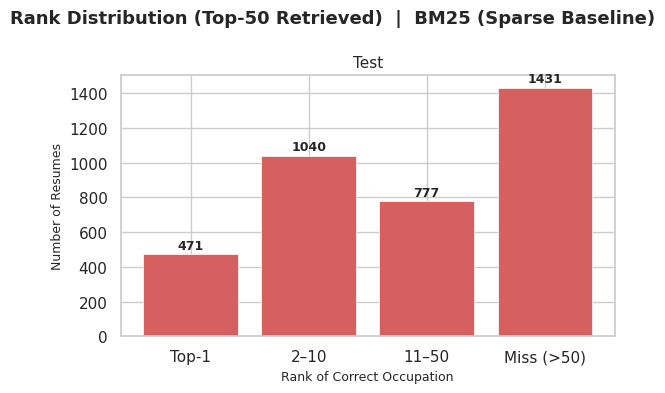

BM25 evaluation complete.


In [ ]:
import numpy as np

# Load split file
df_test_eval  = pd.read_csv("RecSys_Dataset_Test_Uncapped.csv")
for df in [df_test_eval]:
    df['Aligned_Text'] = df['Aligned_Text'].apply(safe_parse)

eval_sets = {
    'Test' : df_test_eval,
}

# Build BM25 index over O*NET occupation texts
print("Tokenising O*NET corpus for BM25...")
tokenized_corpus = [strict_onet_tokenizer(doc) for doc in occ_texts]
bm25 = BM25Okapi(tokenized_corpus)
print(f"BM25 index built over {len(tokenized_corpus)} occupations.")

# Retrieve candidates for each split
bm25_candidates = {}
for set_name, df_eval in eval_sets.items():
    print(f"\nScoring BM25 — {set_name} set...")
    queries = df_eval['Aligned_Text'].apply(
        lambda x: " ".join(x) if isinstance(x, list) else str(x)
    ).tolist()
    cands = []
    for q in tqdm(queries, desc=f"BM25 {set_name}"):
        tok_q  = strict_onet_tokenizer(q)
        scores = bm25.get_scores(tok_q)
        top    = np.argsort(scores)[::-1][:K_MAX]
        cands.append(occ_codes_map[top].tolist())
    bm25_candidates[set_name] = cands

# Evaluation — Test
bm25_all_metrics = run_full_evaluation(
    model_label      = 'BM25 (Sparse Baseline)',
    candidates_dict  = bm25_candidates,
    eval_sets_dict   = eval_sets
)
print("BM25 evaluation complete.")



## all-MiniLM-L6-v2



Loading Default MiniLM-L6 model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/28 [00:00<?, ?it/s]


Retrieving — Test set...


Batches:   0%|          | 0/117 [00:00<?, ?it/s]


######################################################################
#  EVALUATION: Default all-MiniLM-L6-v2
######################################################################

[Default all-MiniLM-L6-v2]


,Test Hit Rate,Test MRR,Test NDCG
@K,,,
1,1.29%,0.0129,0.0516
10,11.72%,0.0373,0.1183
50,39.37%,0.0505,0.1844


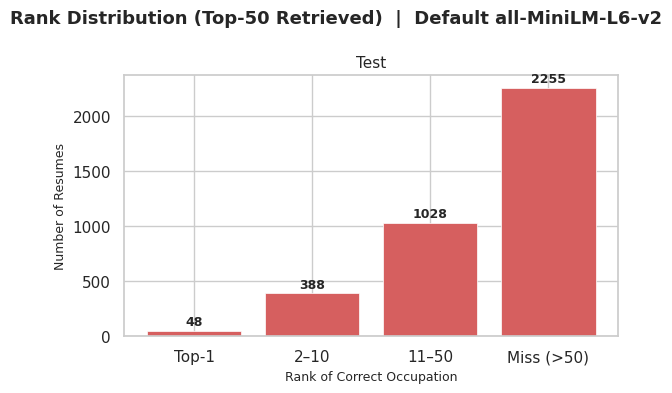

Default MiniLM-L6 evaluation complete.


In [ ]:
# MiniLM-L6 — Default
FT_OUTPUT_DIR_MINILM = 'minilm-l6-onet-recsys-finetuned'

# Load split files
df_test_eval  = pd.read_csv("RecSys_Dataset_Test_Uncapped.csv")
for df in [df_test_eval]:
    df['Aligned_Text'] = df['Aligned_Text'].apply(safe_parse)

eval_sets = {
    'Test' : df_test_eval,
}

print("Loading Default MiniLM-L6 model...")
minilm_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2').to(device)
minilm_model.max_seq_length = 256

print("Encoding occupation corpus and building FAISS index...")
minilm_index = build_index(minilm_model)

minilm_default_candidates = {}
for set_name, df_eval in eval_sets.items():
    print(f"\nRetrieving — {set_name} set...")
    minilm_default_candidates[set_name] = retrieve(minilm_model, minilm_index, df_eval)

# Default model: Test
minilm_default_metrics = run_full_evaluation(
    model_label      = 'Default all-MiniLM-L6-v2',
    candidates_dict  = minilm_default_candidates,
    eval_sets_dict   = eval_sets
)

del minilm_model, minilm_index
torch.cuda.empty_cache()
print("Default MiniLM-L6 evaluation complete.")


## E5-Base-v2



Loading Default E5-Base-v2 model...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/28 [00:00<?, ?it/s]


Retrieving — Test set...


Batches:   0%|          | 0/117 [00:00<?, ?it/s]


######################################################################
#  EVALUATION: Default intfloat/e5-base-v2
######################################################################

[Default intfloat/e5-base-v2]


,Test Hit Rate,Test MRR,Test NDCG
@K,,,
1,4.76%,0.0476,0.0938
10,31.59%,0.1099,0.1954
50,67.06%,0.1284,0.2810


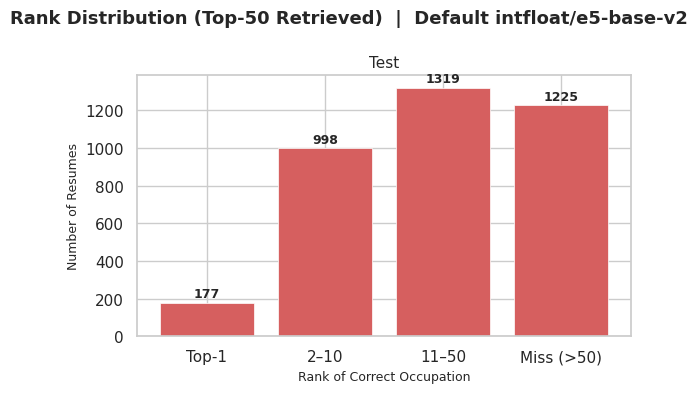

Default E5-Base-v2 evaluation complete.


In [ ]:
# E5-Base-v2 
FT_OUTPUT_DIR_E5 = 'e5-base-onet-recsys-finetuned'

# Load split files — Test
df_test_eval  = pd.read_csv("RecSys_Dataset_Test_Uncapped.csv")
for df in [df_test_eval]:
    df['Aligned_Text'] = df['Aligned_Text'].apply(safe_parse)

eval_sets = {
    'Test' : df_test_eval,
}

print("Loading Default E5-Base-v2 model...")
e5_model = SentenceTransformer('intfloat/e5-base-v2').to(device)
e5_model.max_seq_length = 256

# E5 requires "passage: " prefix on documents
print("Encoding occupation corpus (with 'passage: ' prefix) and building FAISS index...")
e5_index = build_index_with_prefix(e5_model, corpus_prefix="passage: ")

e5_default_candidates = {}
for set_name, df_eval in eval_sets.items():
    print(f"\nRetrieving — {set_name} set...")
    e5_default_candidates[set_name] = retrieve_with_prefix(
        e5_model, e5_index, df_eval, query_prefix="query: "
    )

# Default model: Test
e5_default_metrics = run_full_evaluation(
    model_label      = 'Default intfloat/e5-base-v2',
    candidates_dict  = e5_default_candidates,
    eval_sets_dict   = eval_sets
)

del e5_model, e5_index
torch.cuda.empty_cache()
print("Default E5-Base-v2 evaluation complete.")



## all-mpnet-base-v2



Loading Default MPNet-Base-v2 model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/28 [00:00<?, ?it/s]


Retrieving — Test set...


Batches:   0%|          | 0/117 [00:00<?, ?it/s]


######################################################################
#  EVALUATION: Default all-mpnet-base-v2
######################################################################

[Default all-mpnet-base-v2]


,Test Hit Rate,Test MRR,Test NDCG
@K,,,
1,10.46%,0.1046,0.1698
10,45.42%,0.1918,0.2899
50,72.63%,0.2060,0.3461


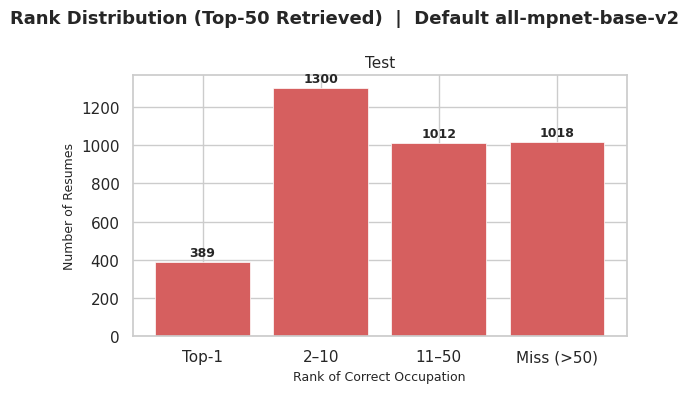

Default MPNet-Base-v2 evaluation complete.


In [ ]:
# MPNet-Base-v2 — Default
FT_OUTPUT_DIR_MPNET = 'mpnet-base-onet-recsys-finetuned'

# Load split files — Test
df_test_eval  = pd.read_csv("RecSys_Dataset_Test_Uncapped.csv")
for df in [df_test_eval]:
    df['Aligned_Text'] = df['Aligned_Text'].apply(safe_parse)

eval_sets = {
    'Test' : df_test_eval,
}

print("Loading Default MPNet-Base-v2 model...")
mpnet_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2').to(device)
mpnet_model.max_seq_length = 256

print("Encoding occupation corpus and building FAISS index...")
mpnet_index = build_index(mpnet_model)     # symmetric — no prefix on docs

mpnet_default_candidates = {}
for set_name, df_eval in eval_sets.items():
    print(f"\nRetrieving — {set_name} set...")
    mpnet_default_candidates[set_name] = retrieve(mpnet_model, mpnet_index, df_eval)

# Default model: Test 
mpnet_default_metrics = run_full_evaluation(
    model_label      = 'Default all-mpnet-base-v2',
    candidates_dict  = mpnet_default_candidates,
    eval_sets_dict   = eval_sets
)

del mpnet_model, mpnet_index
torch.cuda.empty_cache()
print("Default MPNet-Base-v2 evaluation complete.")


## BGE-Large-en-v1.5



Loading Default BGE-Large-en-v1.5 model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/28 [00:00<?, ?it/s]


Retrieving — Test set...


Batches:   0%|          | 0/117 [00:00<?, ?it/s]


######################################################################
#  EVALUATION: Default BAAI/bge-large-en-v1.5
######################################################################

[Default BAAI/bge-large-en-v1.5]


,Test Hit Rate,Test MRR,Test NDCG
@K,,,
1,5.65%,0.0565,0.1176
10,37.70%,0.1394,0.2260
50,60.39%,0.1503,0.2705


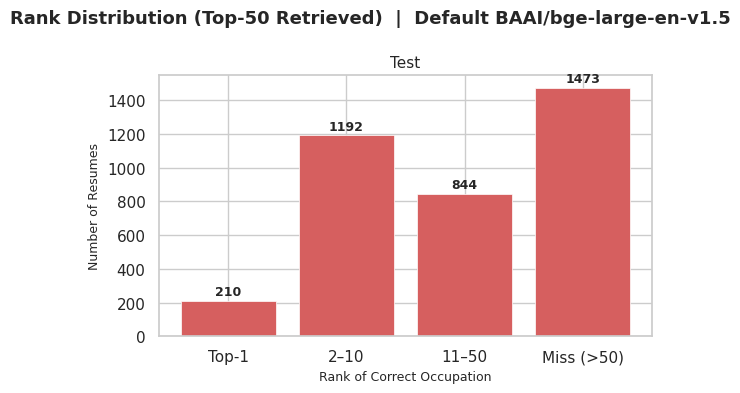

Default BGE-Large-en-v1.5 evaluation complete.


In [ ]:
# BGE-Large-en-v1.5 
FT_OUTPUT_DIR_BGE  = 'bge-large-onet-recsys-finetuned'
BGE_QUERY_PREFIX   = "Represent this sentence for searching relevant passages: "

# Load split files — Test
df_test_eval  = pd.read_csv("RecSys_Dataset_Test_Uncapped.csv")
for df in [df_test_eval]:
    df['Aligned_Text'] = df['Aligned_Text'].apply(safe_parse)

eval_sets = {
    'Test' : df_test_eval,
}

print("Loading Default BGE-Large-en-v1.5 model...")
bge_model = SentenceTransformer('BAAI/bge-large-en-v1.5').to(device)
bge_model.max_seq_length = 256

# BGE documents have NO prefix — only queries get the instruction prefix
print("Encoding occupation corpus (no prefix) and building FAISS index...")
bge_index = build_index(bge_model)

bge_default_candidates = {}
for set_name, df_eval in eval_sets.items():
    print(f"\nRetrieving — {set_name} set...")
    bge_default_candidates[set_name] = retrieve_with_prefix(
        bge_model, bge_index, df_eval, query_prefix=BGE_QUERY_PREFIX
    )

# Default model: Test
bge_default_metrics = run_full_evaluation(
    model_label      = 'Default BAAI/bge-large-en-v1.5',
    candidates_dict  = bge_default_candidates,
    eval_sets_dict   = eval_sets
)

del bge_model, bge_index
torch.cuda.empty_cache()
gc.collect()
print("Default BGE-Large-en-v1.5 evaluation complete.")



## Default Model Comparison (Test Set)


In [ ]:
# Compare All 5 Default Models on Test Set
import pandas as pd

def metrics_to_rows(model_name, metrics_dict, split='Test'):
    """Convert a model's all_metrics dict into DataFrame rows (one per @K)."""
    rows = []
    for k in K_VALS:
        m = metrics_dict[split][k]
        rows.append({
            'Model'    : model_name,
            '@K'       : k,
            'Hit Rate' : f"{m['HitRate'] :.2f}%",
            'MRR'      : round(m['MRR'],     4),
            'NDCG'     : round(m['NDCG'],    4),
        })
    return rows

rows = []
rows += metrics_to_rows('BM25 (Sparse Baseline)',        bm25_all_metrics)
rows += metrics_to_rows('Default all-MiniLM-L6-v2',     minilm_default_metrics)
rows += metrics_to_rows('Default intfloat/e5-base-v2',  e5_default_metrics)
rows += metrics_to_rows('Default all-mpnet-base-v2',    mpnet_default_metrics)
rows += metrics_to_rows('Default BAAI/bge-large-en-v1.5', bge_default_metrics)

df_default_comparison = pd.DataFrame(rows)
df_default_comparison = df_default_comparison.set_index(['Model', '@K'])

print("=" * 70)
print("  DEFAULT MODEL COMPARISON — Test Set")
print("=" * 70)
display(df_default_comparison)


  DEFAULT MODEL COMPARISON — Test Set


Hit Rate     MRR    NDCG
Model                          @K                         
BM25 (Sparse Baseline)         1    12.66%  0.1266  0.1943
                               10   40.63%  0.2050  0.2827
                               50   61.52%  0.2159  0.3471
Default all-MiniLM-L6-v2       1     1.29%  0.0129  0.0516
                               10   11.72%  0.0373  0.1183
                               50   39.37%  0.0505  0.1844
Default intfloat/e5-base-v2    1     4.76%  0.0476  0.0938
                               10   31.59%  0.1099  0.1954
                               50   67.06%  0.1284  0.2810
Default all-mpnet-base-v2      1    10.46%  0.1046  0.1698
                               10   45.42%  0.1918  0.2899
                               50   72.63%  0.2060  0.3461
Default BAAI/bge-large-en-v1.5 1     5.65%  0.0565  0.1176
                               10   37.70%  0.1394  0.2260
                               50   60.39%  0.1503  0.2705


## Contrastive Fine-Tuning (Setups)


In [ ]:
# Unified Pair Builder (Contrastive Fine-Tuning)

def create_pairs(df, anchor_prefix="", positive_prefix=""):

    anchors, positives = [], []
    skipped = 0

    for _, row in df.iterrows():
        true_code   = row['Mapped_ONET_Code']
        target_text = onet_dict.get(true_code)
        if target_text is None:
            skipped += 1
            continue
        skills = (
            " ".join(row['Aligned_Text'])
            if isinstance(row['Aligned_Text'], list)
            else str(row['Aligned_Text'])
        )
        anchors.append(f"{anchor_prefix}{skills}")
        positives.append(f"{positive_prefix}{target_text}")

    print(f"  Pairs built: {len(anchors)} | Skipped: {skipped}")
    return HFDataset.from_dict({'anchor': anchors, 'positive': positives})


print("Unified pair builder defined.")

Unified pair builder defined.


In [ ]:
# BUILD IR EVALUATOR FROM VALIDATION SET
from sentence_transformers import SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.evaluation import InformationRetrievalEvaluator

def build_ir_evaluator(df_eval, evaluator_name, query_prefix=""):
    queries  = {}   # {qid: query_text}
    corpus   = {}   # {cid: doc_text}
    relevant = {}   # {qid: set of relevant cids}

    # Build corpus from full O*NET dictionary
    # Every occupation is a candidate — same as FAISS index at inference
    for code, text in onet_dict.items():
        corpus[code] = text

    # Build queries and ground truth relevance from validation rows
    for idx, row in df_eval.iterrows():
        qid       = str(idx)
        true_code = row['Mapped_ONET_Code']
        skills    = (
            " ".join(row['Aligned_Text'])
            if isinstance(row['Aligned_Text'], list)
            else str(row['Aligned_Text'])
        )
        queries[qid]  = f"{query_prefix}{skills}"
        relevant[qid] = {true_code}   # single ground truth per resume

    return InformationRetrievalEvaluator(
        queries=queries,
        corpus=corpus,
        relevant_docs=relevant,

        accuracy_at_k=[1,10],
        mrr_at_k=[1,10],
        precision_recall_at_k=[1],
        ndcg_at_k=[1],
        map_at_k=[1],

        name=evaluator_name,
        show_progress_bar=False,
    )

# Load validation split for evaluator construction
df_ft_val_ir = pd.read_csv("RecSys_Dataset_Validation_Uncapped.csv")
df_ft_val_ir['Aligned_Text'] = df_ft_val_ir['Aligned_Text'].apply(safe_parse)

## MNRL Contrastive Fine-Tuning on all-mpnet-base-v2

Building training pairs...
  Pairs built: 3789 | Skipped: 0
  Pairs built: 3719 | Skipped: 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Starting MPNet-Base-v2 fine-tuning with IR-based checkpoint selection...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


  BEST CHECKPOINT SUMMARY — MPNet-Base-v2
  Checkpoint path            : mpnet-base-onet-recsys-finetuned/checkpoint-1000
  Best step                  : 1000
  Best MRR@10 (Val)          : 0.5308
  Eval loss                  : 0.7559
  Epoch at best              : 4.22



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to: mpnet-base-onet-recsys-finetuned


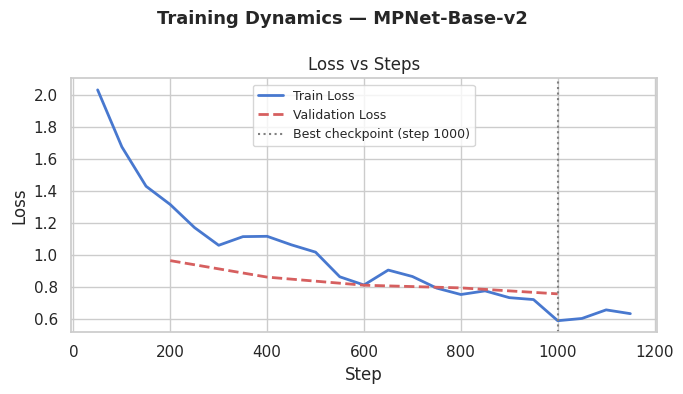


Loading Fine-Tuned MPNet-Base-v2 for evaluation...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/28 [00:00<?, ?it/s]


Retrieving — Train set...


Batches:   0%|          | 0/119 [00:00<?, ?it/s]


Retrieving — Test set...


Batches:   0%|          | 0/117 [00:00<?, ?it/s]


######################################################################
#  EVALUATION: Default vs Fine-Tuned MPNet-Base-v2
######################################################################

[Default vs Fine-Tuned MPNet-Base-v2]


,Train Hit Rate,Train MRR,Train NDCG,Test Hit Rate,Test MRR,Test NDCG
@K,,,,,,
1,49.75%,0.4975,0.5310,43.64%,0.4364,0.4792
10,80.15%,0.5930,0.4784,75.61%,0.5378,0.4539
50,92.77%,0.5994,0.4239,87.09%,0.5435,0.4094


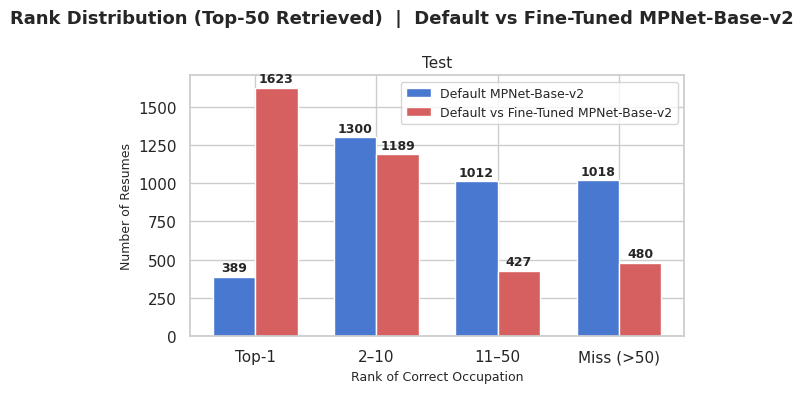

Fine-Tuned MPNet-Base-v2 evaluation complete.


In [ ]:
from datasets import Dataset as HFDataset
from sentence_transformers import losses as st_losses
from sentence_transformers import SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.evaluation import InformationRetrievalEvaluator

df_ft_train = pd.read_csv("RecSys_Dataset_Train_Capped.csv")
df_ft_val   = pd.read_csv("RecSys_Dataset_Validation_Uncapped.csv")
for df in [df_ft_train, df_ft_val]:
    df['Aligned_Text'] = df['Aligned_Text'].apply(safe_parse)

print("Building training pairs...")
train_ds_mpnet = create_pairs(df_ft_train)
val_ds_mpnet   = create_pairs(df_ft_val)

ir_evaluator_mpnet = build_ir_evaluator(
    df_eval        = df_ft_val_ir,
    evaluator_name = "mpnet-val-ir",
    query_prefix   = ""
)

ft_mpnet = SentenceTransformer('sentence-transformers/all-mpnet-base-v2').to(device)
ft_mpnet.max_seq_length = 256
mpnet_loss = st_losses.MultipleNegativesRankingLoss(model=ft_mpnet)

mpnet_training_args = SentenceTransformerTrainingArguments(
    output_dir=FT_OUTPUT_DIR_MPNET,
    seed=42,
    data_seed=42,
    num_train_epochs=5,
    learning_rate=4e-5,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    warmup_steps=0.1,
    fp16=True,
    eval_strategy='steps',
    eval_steps=200,
    save_strategy='steps',
    save_steps=200,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="mpnet-val-ir_cosine_mrr@10",
    greater_is_better=True,
)

mpnet_trainer = SentenceTransformerTrainer(
    model=ft_mpnet,
    args=mpnet_training_args,
    train_dataset=train_ds_mpnet,
    eval_dataset=val_ds_mpnet,
    evaluator=ir_evaluator_mpnet,
    loss=mpnet_loss,
)

# Fine-tune 
print("Starting MPNet-Base-v2 fine-tuning with IR-based checkpoint selection...")
mpnet_trainer.train()

#  Best checkpoint summary 
best_ckpt   = mpnet_trainer.state.best_model_checkpoint
best_metric = mpnet_trainer.state.best_metric
best_step   = int(best_ckpt.split("-")[-1]) if best_ckpt else None
best_log    = next(
    (l for l in reversed(mpnet_trainer.state.log_history)
     if l.get("step") == best_step and "eval_loss" in l),
    None
)
print("\n" + "="*60)
print("  BEST CHECKPOINT SUMMARY — MPNet-Base-v2")
print("="*60)
print(f"  Checkpoint path            : {best_ckpt}")
print(f"  Best step                  : {best_step}")
print(f"  Best MRR@10 (Val)          : {best_metric:.4f}")
print(f"  Eval loss                  : {best_log.get('eval_loss', 'n/a'):.4f}" if best_log else "  Eval loss                  : n/a")
print(f"  Epoch at best              : {best_log.get('epoch', 'n/a'):.2f}" if best_log else "  Epoch at best              : n/a")
print("="*60 + "\n")


# Plot training curve
plot_training_curves(mpnet_trainer, "MPNet-Base-v2", best_step)

# Load best checkpoint for evaluation 
print("\nLoading Fine-Tuned MPNet-Base-v2 for evaluation...")
ft_mpnet_eval = SentenceTransformer(FT_OUTPUT_DIR_MPNET).to(device)
ft_mpnet_eval.max_seq_length = 256
ft_mpnet_index = build_index(ft_mpnet_eval)

# Final tuned model: Train + Test
df_train_final = pd.read_csv("RecSys_Dataset_Train_Capped.csv")
df_test_final  = pd.read_csv("RecSys_Dataset_Test_Uncapped.csv")
for df in [df_train_final, df_test_final]:
    df['Aligned_Text'] = df['Aligned_Text'].apply(safe_parse)

eval_sets_final = {'Train': df_train_final, 'Test': df_test_final}
ft_mpnet_candidates = {}
for set_name, df_eval in eval_sets_final.items():
    print(f"\nRetrieving — {set_name} set...")
    ft_mpnet_candidates[set_name] = retrieve(ft_mpnet_eval, ft_mpnet_index, df_eval)

mpnet_ft_metrics = run_full_evaluation(
    model_label       = 'Default vs Fine-Tuned MPNet-Base-v2',
    candidates_dict   = ft_mpnet_candidates,
    eval_sets_dict    = eval_sets_final,
    compare_metrics   = mpnet_default_metrics,
    compare_label     = 'Default MPNet-Base-v2',
)

del ft_mpnet, ft_mpnet_eval, ft_mpnet_index
torch.cuda.empty_cache()
print("Fine-Tuned MPNet-Base-v2 evaluation complete.")



## Default vs Fine-Tuned Comparison (Test Set)


In [ ]:
import pandas as pd

def metrics_to_rows_ft(model_name, metrics_dict, split='Test'):
    rows = []
    for k in K_VALS:
        m = metrics_dict[split][k]
        rows.append({
            'Model'    : model_name,
            '@K'       : k,
            'Hit Rate' : round(m['HitRate'], 2),
            'MRR'      : round(m['MRR'],     4),
            'NDCG'     : round(m['NDCG'],    4),
        })
    return rows

rows_ft = []
rows_ft += metrics_to_rows_ft('Default all-mpnet-base-v2',      mpnet_default_metrics)
rows_ft += metrics_to_rows_ft('Fine-Tuned all-mpnet-base-v2',   mpnet_ft_metrics)

df_mpnet_comparison = pd.DataFrame(rows_ft)
df_mpnet_comparison = df_mpnet_comparison.set_index(['Model', '@K'])

print("=" * 70)
print("  MPNet-Base-v2: Default vs Fine-Tuned — Test Set")
print("=" * 70)
display(df_mpnet_comparison)


  MPNet-Base-v2: Default vs Fine-Tuned — Test Set


Hit Rate     MRR    NDCG
Model                        @K                          
Default all-mpnet-base-v2    1      10.46  0.1046  0.1698
                             10     45.42  0.1918  0.2899
                             50     72.63  0.2060  0.3461
Fine-Tuned all-mpnet-base-v2 1      43.64  0.4364  0.4792
                             10     75.61  0.5378  0.4539
                             50     87.09  0.5435  0.4094

In [ ]:
# Download the fine-tuned model
FT_OUTPUT_DIR_MPNET = 'mpnet-base-onet-recsys-finetuned'

ft_mpnet.save_pretrained(FT_OUTPUT_DIR_MPNET)
print(f"Fine-tuned mpnet saved to: {FT_OUTPUT_DIR_MPNET}")

Fine-tuned mpnet saved to: mpnet-base-onet-recsys-finetuned
